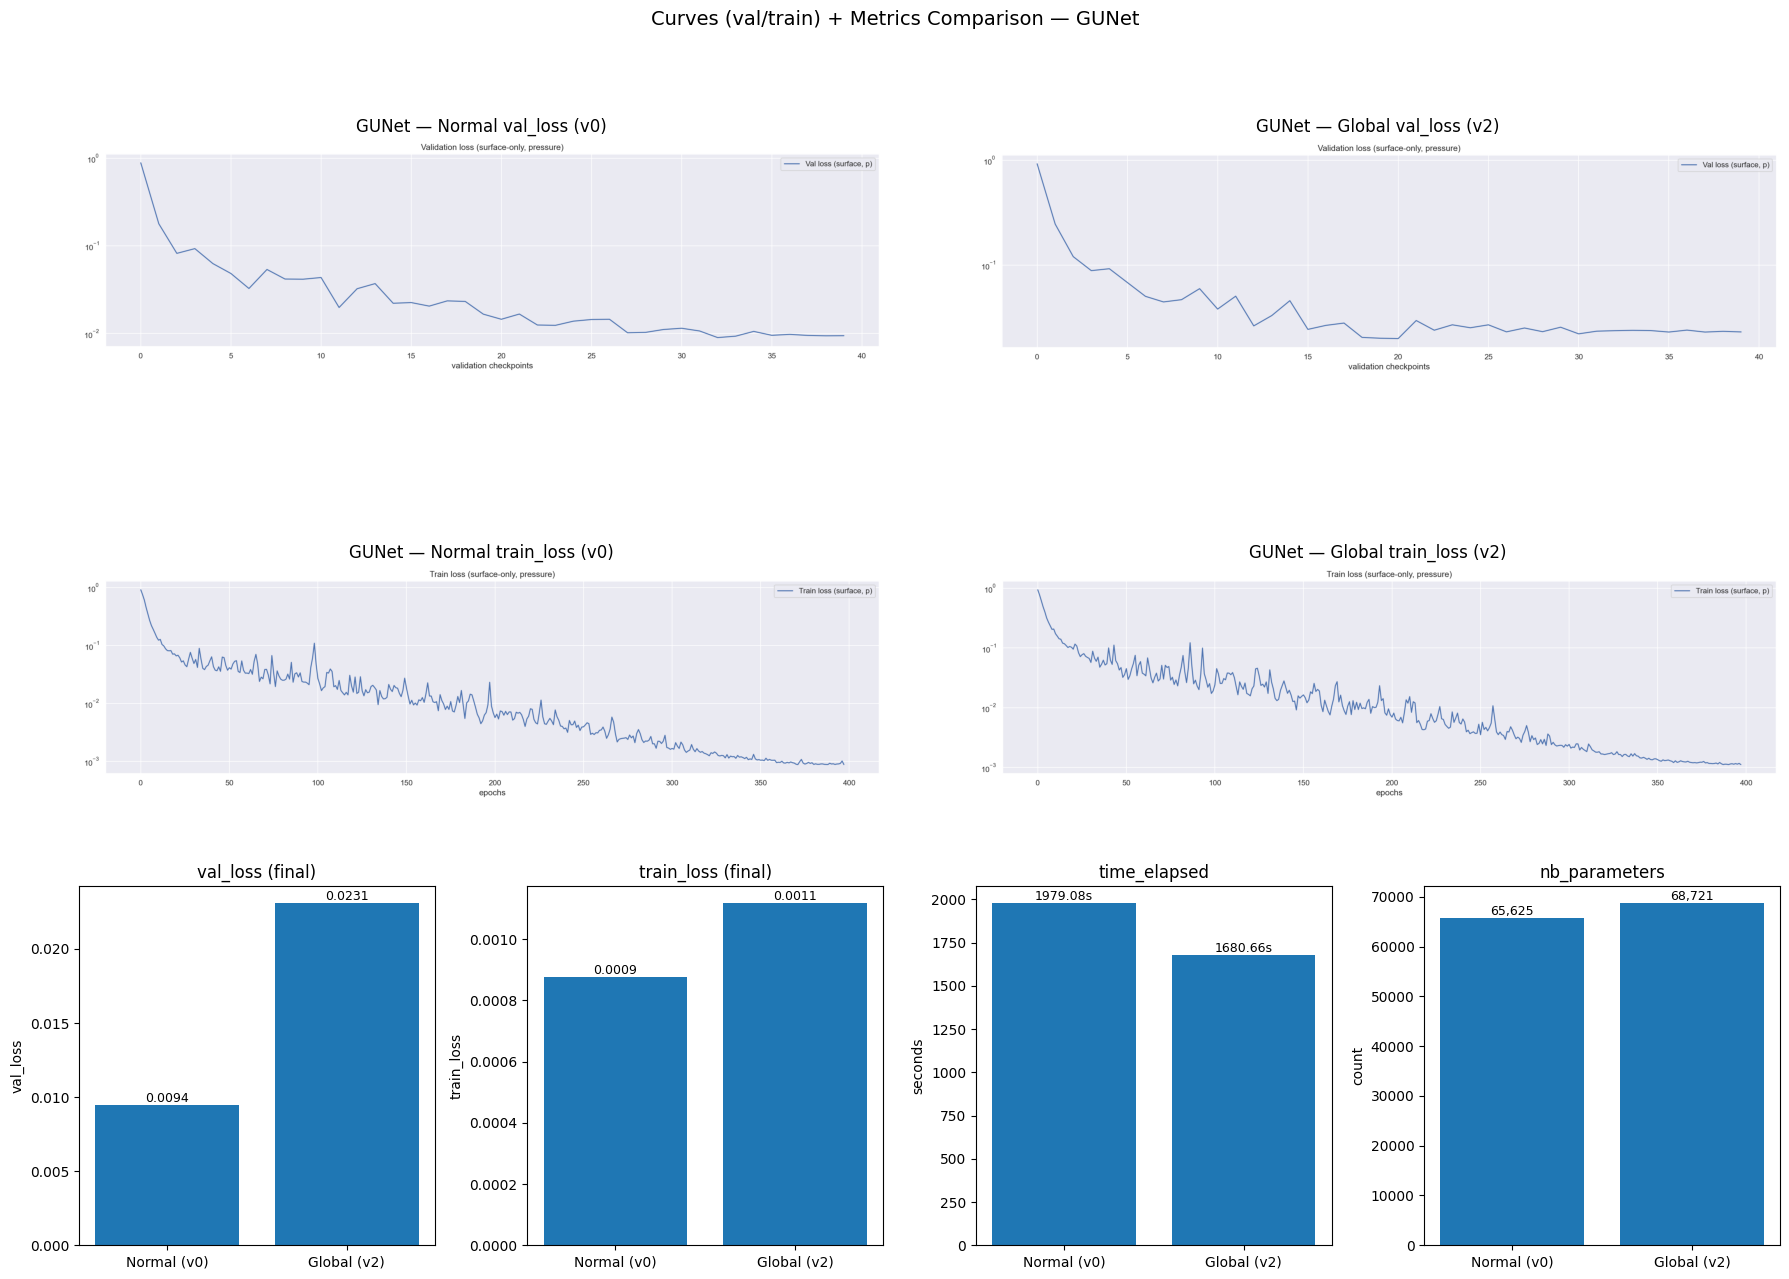

Saved -> comparisons\GUNet_curves_train_val_metrics.png


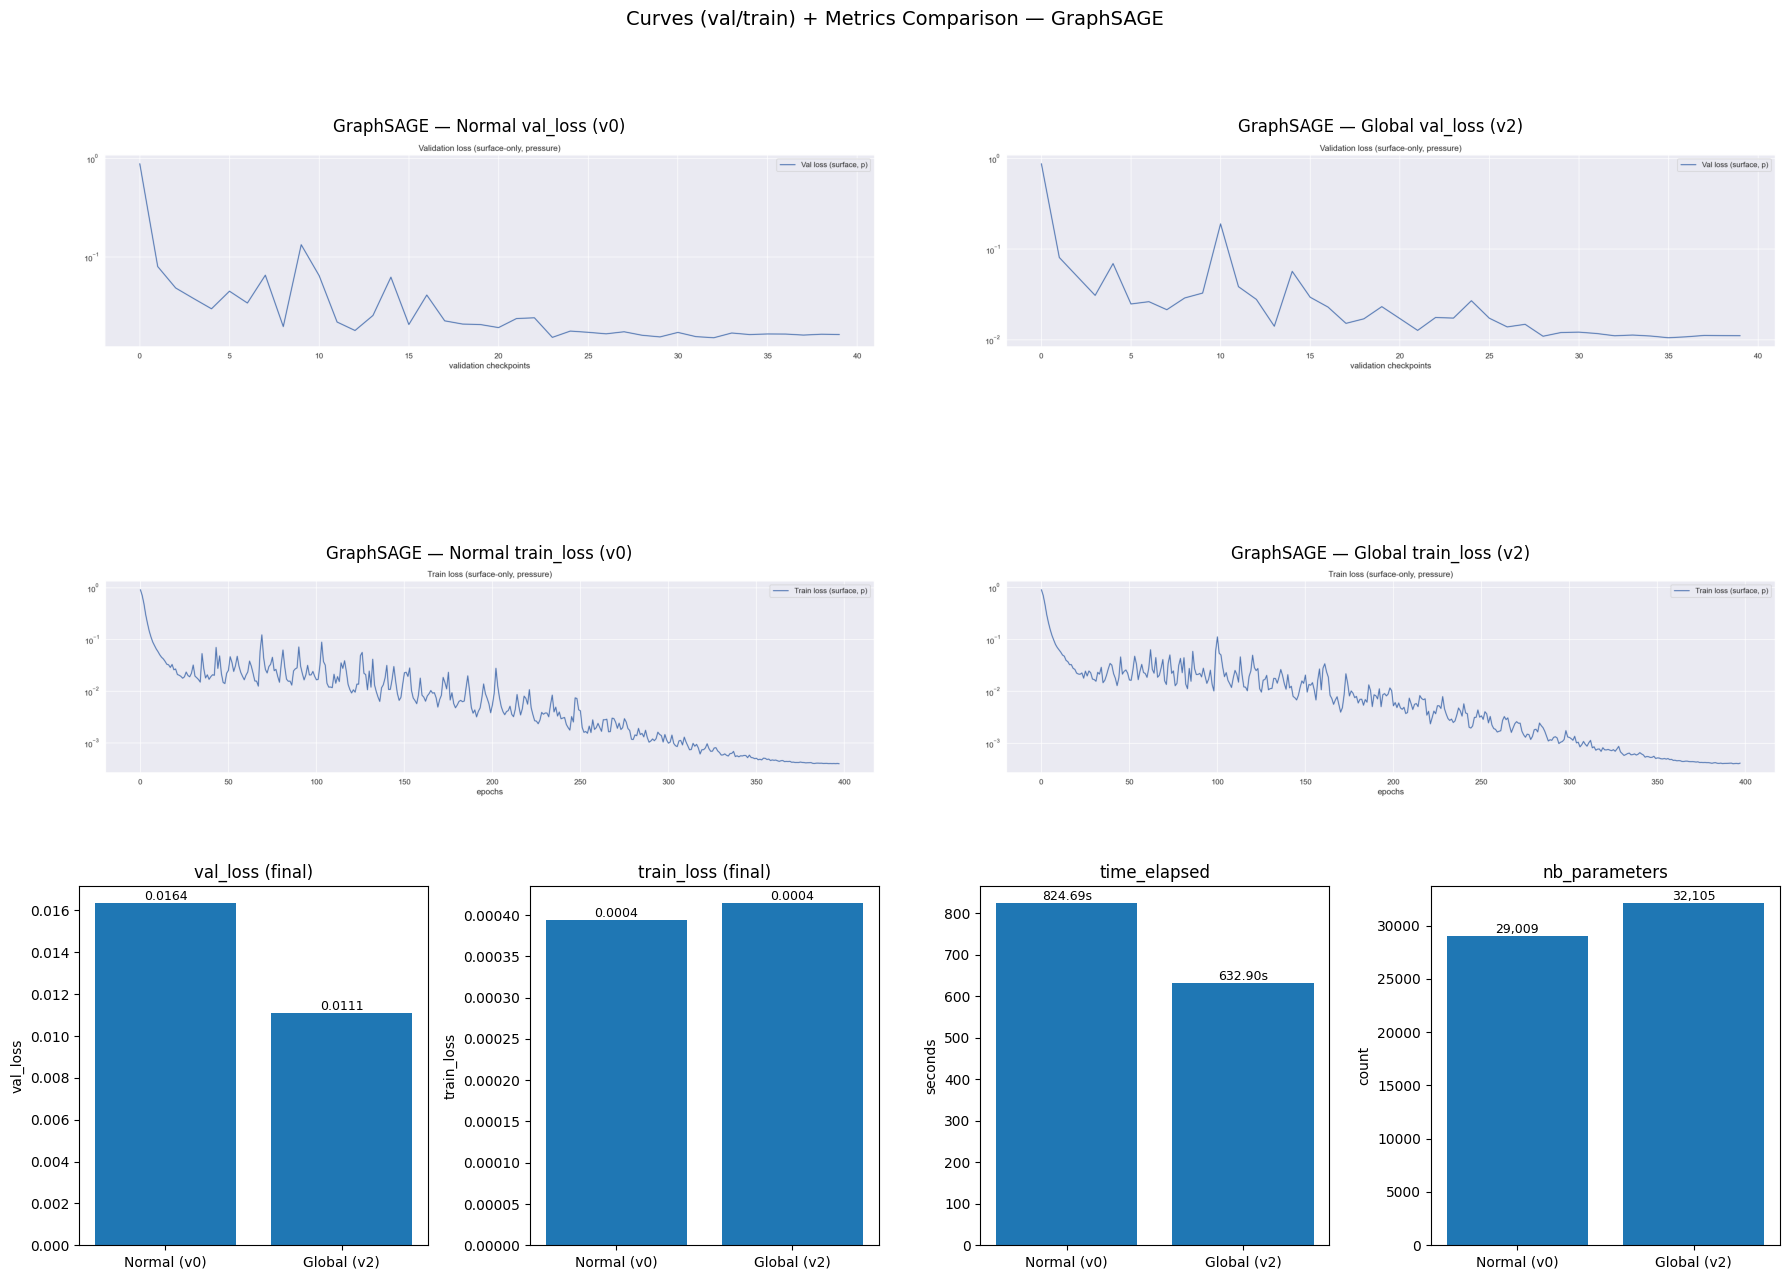

Saved -> comparisons\GraphSAGE_curves_train_val_metrics.png


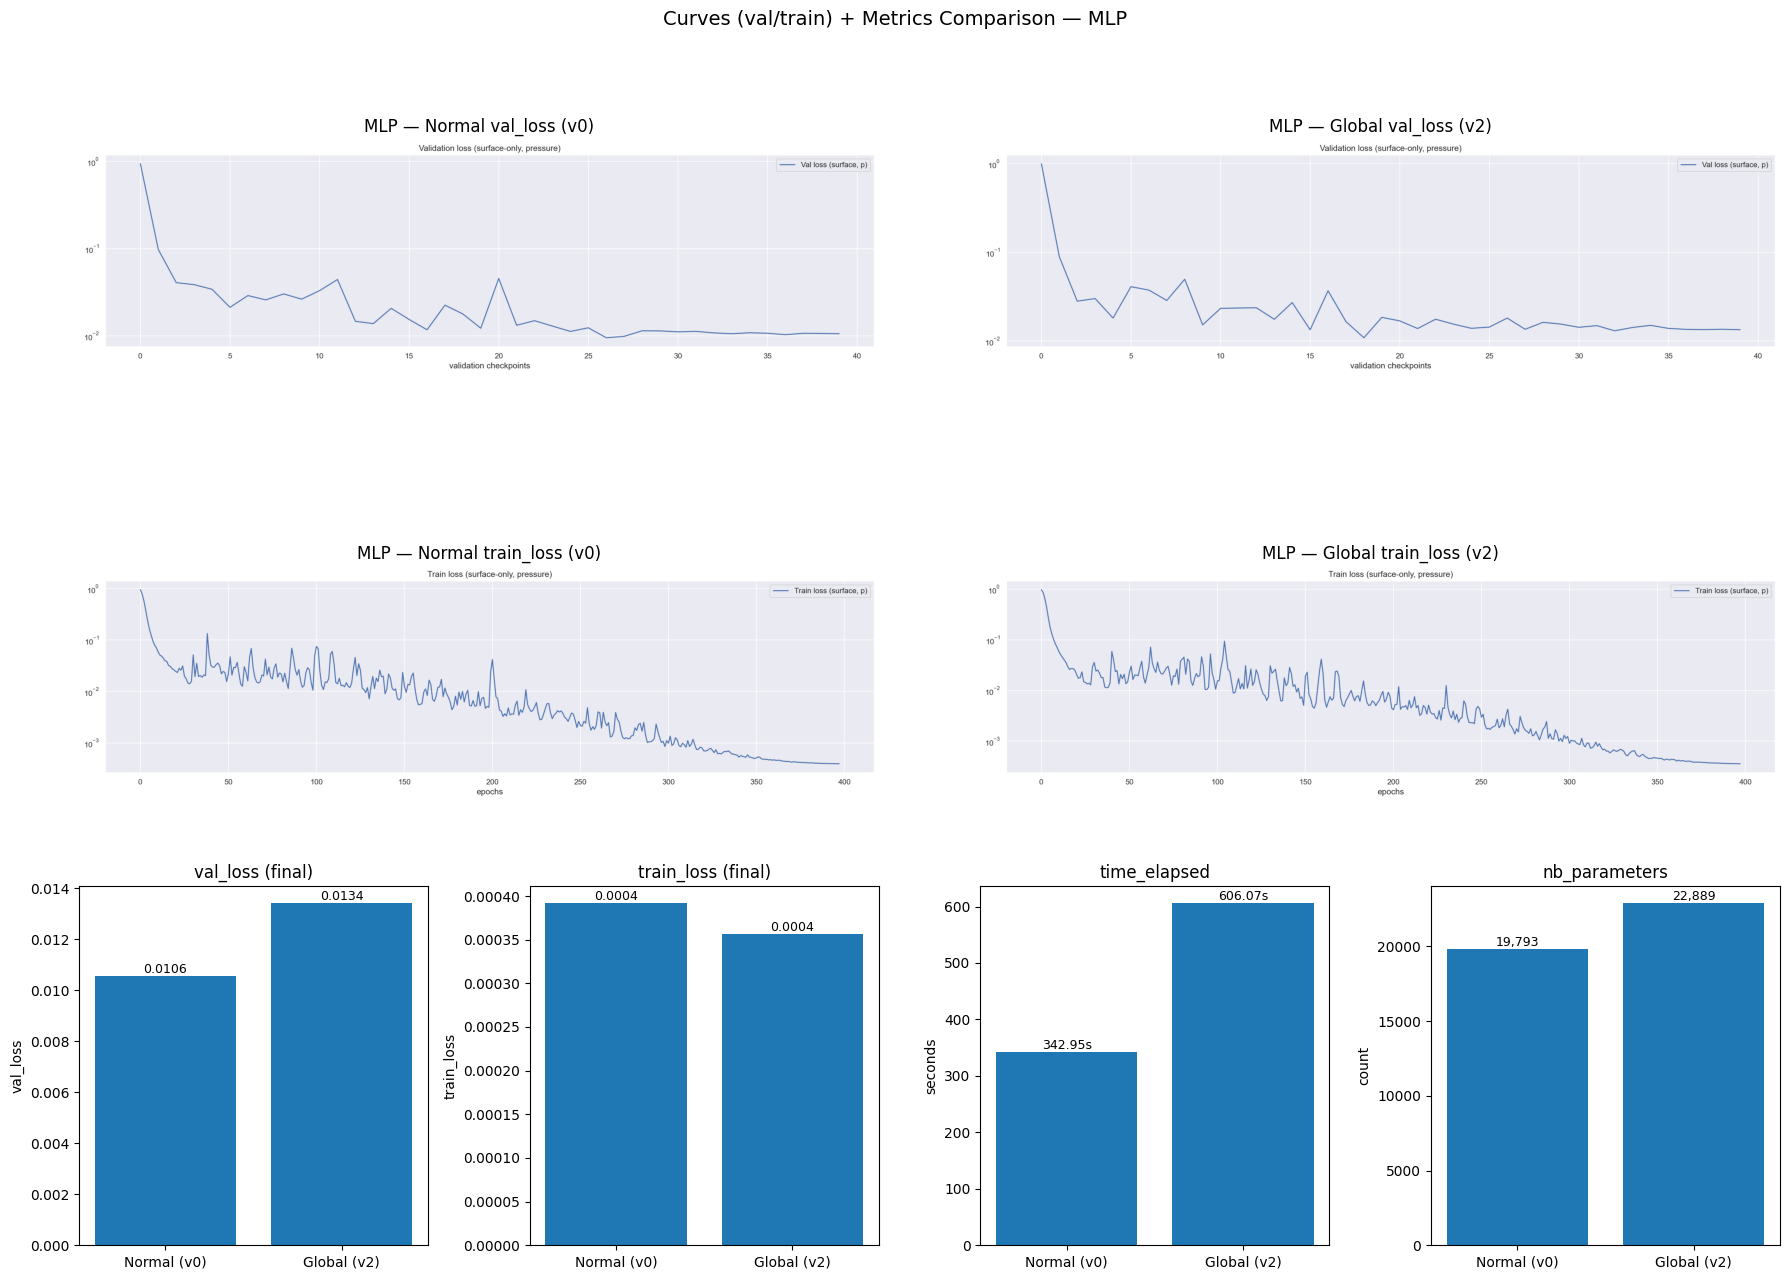

Saved -> comparisons\MLP_curves_train_val_metrics.png


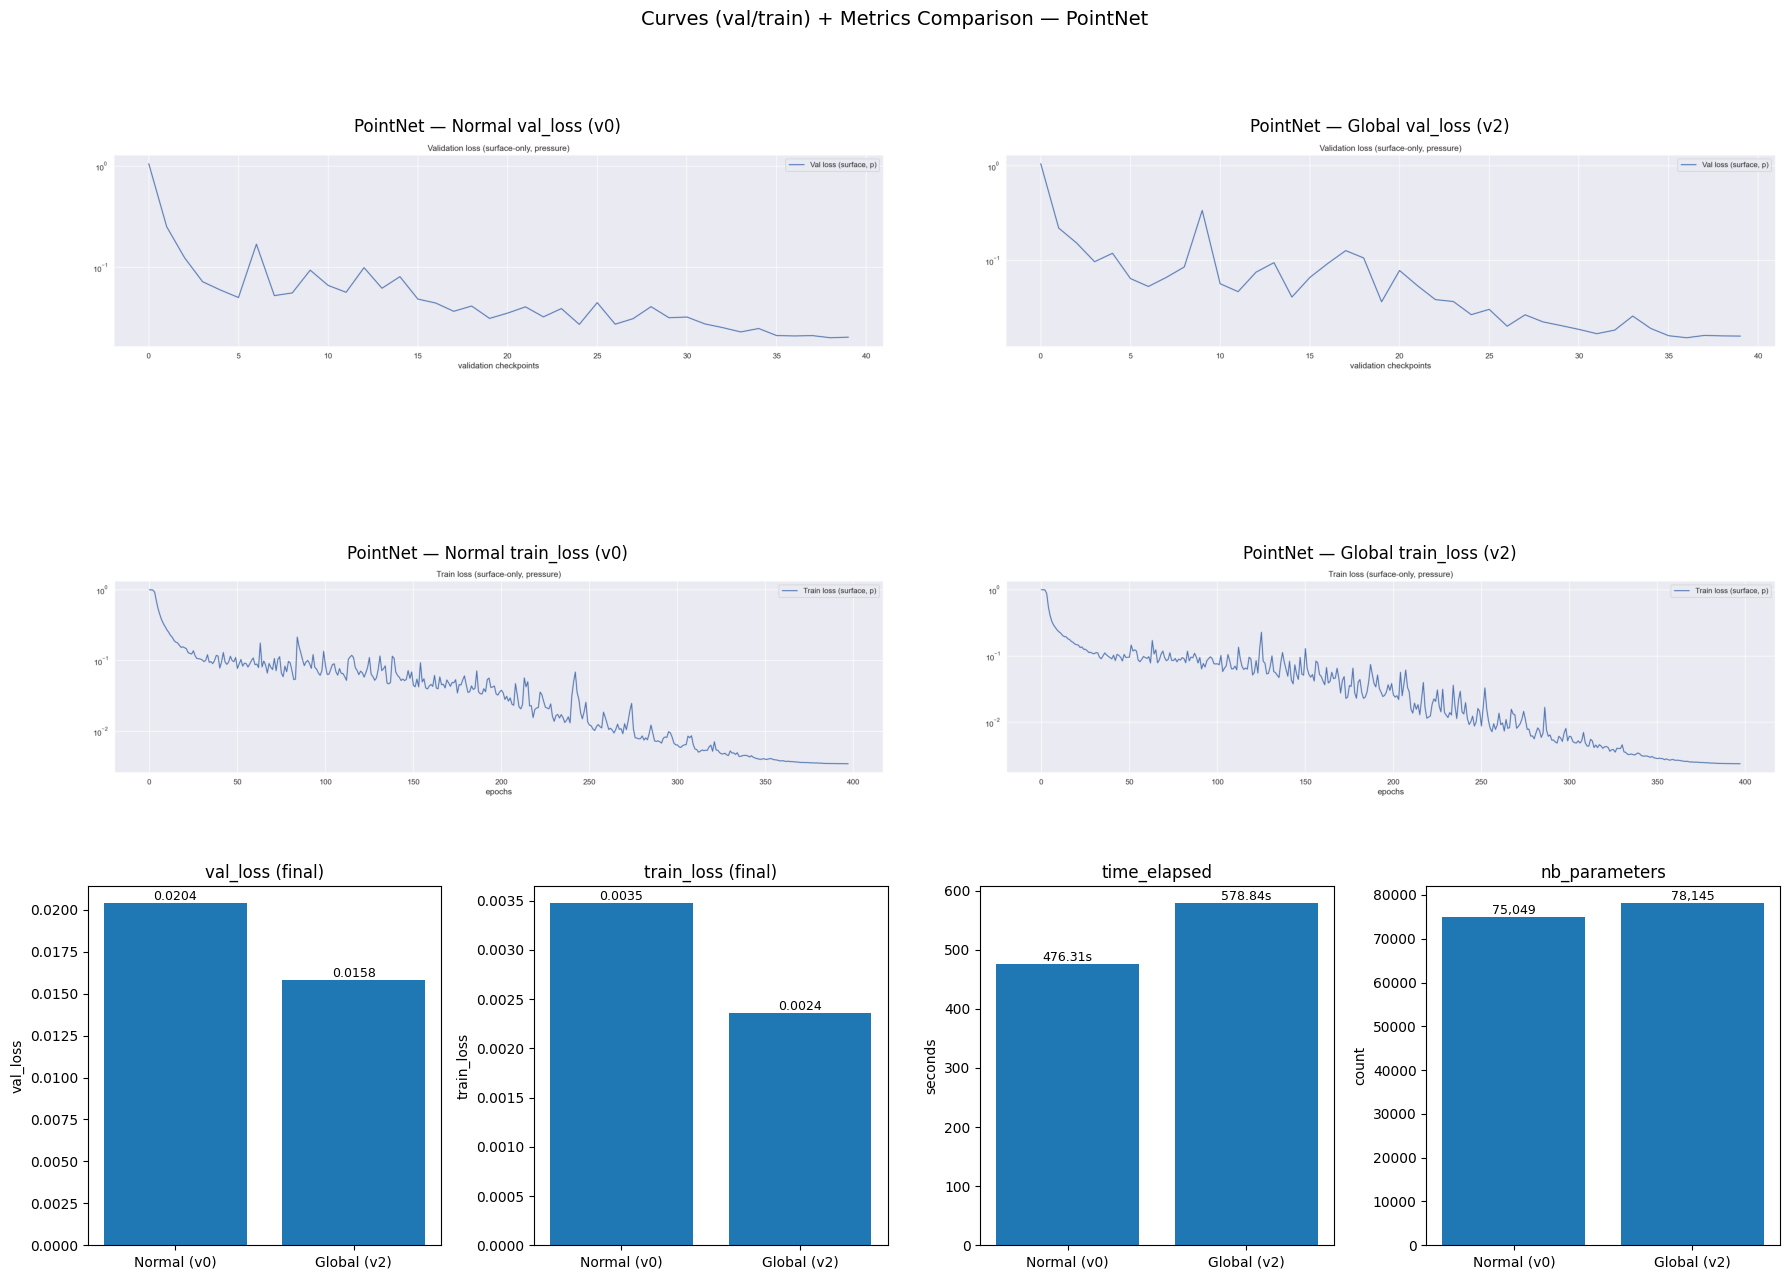

Saved -> comparisons\PointNet_curves_train_val_metrics.png


In [1]:
# --- Full comparison: val/train curves + scalar metrics ---
from pathlib import Path
import re, json, math
import matplotlib.pyplot as plt
from PIL import Image

# ---------- Config ----------
SEARCH_ROOT = Path(".")
OUT_DIR = Path("comparisons")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# ---------- Helpers ----------
def safe_get(d, *keys, default=None):
    cur = d
    for k in keys:
        if isinstance(cur, dict) and k in cur:
            cur = cur[k]
        else:
            return default
    return cur

def infer_variant_and_base(stem):
    name = stem.replace("_log", "")
    if name.endswith("Global"):
        return name[:-6], "Global"
    return name, "Normal"

def normalize_path(s):
    return re.sub(r"[^a-z0-9]+", "", str(s).lower())

def infer_scarce_version(path_str, variant):
    p = normalize_path(path_str)
    if "scarcev0" in p: return "scarce_v0"
    if "scarcev2" in p: return "scarce_v2"
    if "scarcev1" in p: return "scarce_v1"
    return "scarce_v2" if variant == "Global" else "scarce_v0"

def load_relaxed_json(path: Path):
    txt = path.read_text(encoding="utf-8", errors="ignore").strip()
    try:
        return json.loads(txt)
    except json.JSONDecodeError:
        pass
    # Parse multiple concatenated JSON objects
    objs, depth, in_str, esc, start = [], 0, False, False, None
    for i, ch in enumerate(txt):
        if in_str:
            if esc: esc = False
            elif ch == "\\": esc = True
            elif ch == '"': in_str = False
        else:
            if ch == '"': in_str = True
            elif ch == "{":
                if depth == 0: start = i
                depth += 1
            elif ch == "}":
                depth -= 1
                if depth == 0 and start is not None:
                    frag = txt[start:i+1]
                    try: objs.append(json.loads(frag))
                    except: pass
                    start = None
    if not objs:
        raise ValueError(f"No valid JSON in {path}")
    for obj in reversed(objs):
        if isinstance(obj, dict) and ("val_loss" in obj or "train_loss" in obj):
            return obj
    return objs[-1]

def _fmt(v, kind="float"):
    try:
        if v is None or (isinstance(v, float) and (math.isnan(v) or math.isinf(v))):
            return "N/A"
        if kind == "int":
            return f"{int(v):,}"
        if kind == "time":
            return f"{float(v):.2f}s"
        return f"{float(v):.4f}"
    except Exception:
        return "N/A"

def _num(v):
    try:
        if v is None: return None
        f = float(v)
        if math.isnan(f) or math.isinf(f): return None
        return f
    except Exception:
        return None

def _bar(ax, labels, values, title, ylabel, fmt_kind="float"):
    heights = [(_num(v) if _num(v) is not None else 0.0) for v in values]
    ax.bar(labels, heights)
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    for i, v in enumerate(values):
        ax.text(i, heights[i], _fmt(v, fmt_kind), ha="center", va="bottom", fontsize=9)

# ---------- Main ----------
def make_curve_plus_bar_panels():
    entries = {}
    for f in SEARCH_ROOT.rglob("*_log.json"):
        try:
            data = load_relaxed_json(f)
        except Exception as e:
            print(f"⚠️ Skipping {f}: {e}")
            continue
        base, variant = infer_variant_and_base(f.stem)
        scarce_version = infer_scarce_version(f, variant)
        if scarce_version not in ("scarce_v0", "scarce_v2"):
            continue
        entries[(base, variant)] = {
            "log": f,
            "val":  safe_get(data, "val_loss"),
            "train": safe_get(data, "train_loss"),
            "time": safe_get(data, "time_elapsed"),
            "params": safe_get(data, "nb_parameters"),
            "scarce_version": scarce_version,
        }

    model_bases = sorted({k[0] for k in entries.keys()})
    any_pair = False
    for model in model_bases:
        n = entries.get((model, "Normal"))
        g = entries.get((model, "Global"))
        if not n or not g:
            continue
        if n["scarce_version"] != "scarce_v0" or g["scarce_version"] != "scarce_v2":
            continue
        any_pair = True

        normal_dir = n["log"].parent
        global_dir = g["log"].parent

        # PNGs
        normal_val = normal_dir / "val_loss.png"
        global_val = global_dir / "val_loss.png"
        normal_train = normal_dir / "train_loss.png"
        global_train = global_dir / "train_loss.png"

        # Load images if they exist
        img_nv = Image.open(normal_val) if normal_val.exists() else None
        img_gv = Image.open(global_val) if global_val.exists() else None
        img_nt = Image.open(normal_train) if normal_train.exists() else None
        img_gt = Image.open(global_train) if global_train.exists() else None

        if not img_nv: print(f"⚠️ {model}: missing Normal val_loss.png")
        if not img_gv: print(f"⚠️ {model}: missing Global val_loss.png")
        if not img_nt: print(f"⚠️ {model}: missing Normal train_loss.png")
        if not img_gt: print(f"⚠️ {model}: missing Global train_loss.png")

        # Scalars
        val_n, val_g = n["val"], g["val"]
        tr_n, tr_g   = n["train"], g["train"]
        t_n,  t_g    = n["time"], g["time"]
        p_n,  p_g    = n["params"], g["params"]

        # --- Figure layout ---
        fig = plt.figure(figsize=(18, 13))
        gs = fig.add_gridspec(3, 4, height_ratios=[2.5, 2.5, 2])

        # Row 1: val_loss.png (Normal | Global)
        ax_nv = fig.add_subplot(gs[0, 0:2])
        ax_gv = fig.add_subplot(gs[0, 2:4])
        # Row 2: train_loss.png (Normal | Global)
        ax_nt = fig.add_subplot(gs[1, 0:2])
        ax_gt = fig.add_subplot(gs[1, 2:4])
        # Row 3: 4 metrics bars
        ax_val  = fig.add_subplot(gs[2, 0])
        ax_tr   = fig.add_subplot(gs[2, 1])
        ax_time = fig.add_subplot(gs[2, 2])
        ax_parm = fig.add_subplot(gs[2, 3])

        # --- Curves ---
        for ax, img, title in [
            (ax_nv, img_nv, f"{model} — Normal val_loss (v0)"),
            (ax_gv, img_gv, f"{model} — Global val_loss (v2)"),
            (ax_nt, img_nt, f"{model} — Normal train_loss (v0)"),
            (ax_gt, img_gt, f"{model} — Global train_loss (v2)")
        ]:
            if img:
                ax.imshow(img); ax.axis("off")
            else:
                ax.text(0.5, 0.5, "Missing image", ha="center", va="center")
                ax.axis("off")
            ax.set_title(title)

        # --- Bars ---
        labels = ["Normal (v0)", "Global (v2)"]
        _bar(ax_val,  labels, [val_n, val_g],  "val_loss (final)",   "val_loss", fmt_kind="float")
        _bar(ax_tr,   labels, [tr_n,  tr_g],   "train_loss (final)", "train_loss", fmt_kind="float")
        _bar(ax_time, labels, [t_n,   t_g],    "time_elapsed",       "seconds", fmt_kind="time")
        _bar(ax_parm, labels, [p_n,   p_g],    "nb_parameters",      "count", fmt_kind="int")

        fig.suptitle(f"Curves (val/train) + Metrics Comparison — {model}", fontsize=14)
        fig.tight_layout()

        out = OUT_DIR / f"{model}_curves_train_val_metrics.png"
        fig.savefig(out, dpi=150, bbox_inches="tight")
        plt.show()
        print(f"Saved -> {out}")

    if not any_pair:
        print("No complete Normal (v0) vs Global (v2) pairs found.")

# ---- Run ----
make_curve_plus_bar_panels()
